## **Experiment 1: IRIS Image Classification**

## Load IRIS dataset

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Pre-Process the IRIS dataset

In [ ]:
from tensorflow.keras.utils import to_categorical

# Normalize the features
X_train = X_train / X_train.max(axis=0)
X_test = X_test / X_test.max(axis=0)

# One-hot encode the labels
y_train = to_categorical(y_train, 3)
y_test = to_categorical(y_test, 3)


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))


Epoch 1/50
4/4 [==============================] - 2s 94ms/step - loss: 1.0919 - accuracy: 0.3333 - val_loss: 1.0735 - val_accuracy: 0.3333
Epoch 2/50
4/4 [==============================] - 0s 20ms/step - loss: 1.0689 - accuracy: 0.3500 - val_loss: 1.0521 - val_accuracy: 0.4667
Epoch 3/50
4/4 [==============================] - 0s 22ms/step - loss: 1.0480 - accuracy: 0.8833 - val_loss: 1.0296 - val_accuracy: 0.9000
Epoch 4/50
4/4 [==============================] - 0s 15ms/step - loss: 1.0295 - accuracy: 0.8500 - val_loss: 1.0070 - val_accuracy: 0.7000
Epoch 5/50
4/4 [==============================] - 0s 20ms/step - loss: 1.0088 - accuracy: 0.7833 - val_loss: 0.9850 - val_accuracy: 0.7000
Epoch 6/50
4/4 [==============================] - 0s 21ms/step - loss: 0.9883 - accuracy: 0.7417 - val_loss: 0.9628 - val_accuracy: 0.7000
Epoch 7/50
4/4 [==============================] - 0s 20ms/step - loss: 0.9683 - accuracy: 0.7000 - val_loss: 0.9395 - val_accuracy: 0.7000
Epoch 8/50
4/4 [===========

In [ ]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 3)                 99        
                                                                 
Total params: 2,499
Trainable params: 2,499
Non-trainable params: 0
_________________________________________________________________
None


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

1/1 [==============================] - 0s 50ms/step - loss: 0.1995 - accuracy: 0.9667
Test Accuracy: 96.67%


In [ ]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape and normalize the data
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


# Image Classification on MNIST Dataset

## MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# Load MobileNetV2 with pre-trained weights, excluding the top layer
base_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

9406464/9406464 [==============================] - 1s 0us/step


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img

X_train_resized = np.array([img_to_array(array_to_img(im, scale=False).resize((96,96))) for im in X_train])
X_test_resized = np.array([img_to_array(array_to_img(im, scale=False).resize((96,96))) for im in X_test])

# Convert to RGB
X_train_resized = np.repeat(X_train_resized, 3, axis=-1)
X_test_resized = np.repeat(X_test_resized, 3, axis=-1)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_resized, y_train, epochs=5, validation_data=(X_test_resized, y_test))

Epoch 1/5
1875/1875 [==============================] - 1572s 830ms/step - loss: 1.8160 - accuracy: 0.3537 - val_loss: 2.6739 - val_accuracy: 0.2744
Epoch 2/5
1875/1875 [==============================] - 1541s 822ms/step - loss: 1.6977 - accuracy: 0.3893 - val_loss: 2.8630 - val_accuracy: 0.2525
Epoch 3/5
1875/1875 [==============================] - 1539s 821ms/step - loss: 1.6658 - accuracy: 0.4009 - val_loss: 2.1104 - val_accuracy: 0.3365
Epoch 4/5
1875/1875 [==============================] - 1546s 824ms/step - loss: 1.6390 - accuracy: 0.4090 - val_loss: 1.9946 - val_accuracy: 0.3468
Epoch 5/5
1875/1875 [==============================] - 1555s 829ms/step - loss: 1.6234 - accuracy: 0.4123 - val_loss: 1.6941 - val_accuracy: 0.4082


## Custom Model 1 for Image Classification

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

def CNN_Model(input_shape=(28, 28, 1), num_classes=10):
    # Define the input layer
    input_layer = Input(shape=input_shape)

    # The 1st block
    x = Conv2D(64, 3, activation='relu', padding="same")(input_layer)
    x = MaxPooling2D((2, 2), strides=2)(x)
    x = Conv2D(128, 3, padding="same", activation='relu')(x)
    x = MaxPooling2D((2, 2), strides=2)(x)

    # Flatten and add dense layers
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    # Create the Model
    model = Model(inputs=input_layer, outputs=output_layer)

    # Print summary of layers
    print(model.summary())

    return model

In [ ]:
model = CNN_Model(input_shape=(28, 28, 1), num_classes=10)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 64)        640       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 64)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 7, 7, 128)        0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 6272)              0     

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

313/313 [==============================] - 11s 33ms/step - loss: 2.6911 - accuracy: 0.3674
Test Accuracy: 36.74%


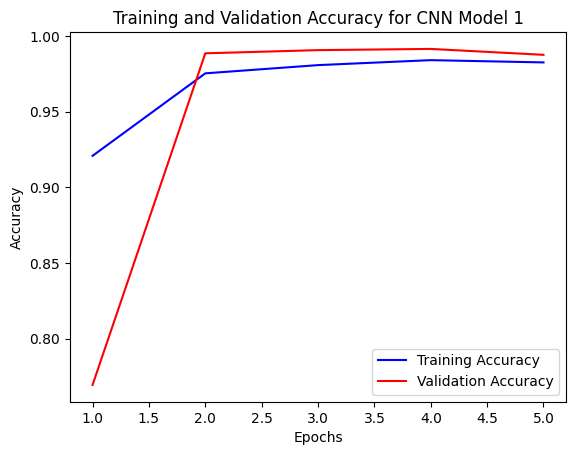

In [ ]:
import matplotlib.pyplot as plt

# Retrieve the training and validation accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Get the number of epochs
epochs = range(1, len(train_accuracy) + 1)

# Plot the training and validation accuracy
plt.plot(epochs, train_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy for CNN Model 1')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l1_l2

def Complex_CNN_Model(input_shape=(28, 28, 1), num_classes=10):
    # Define the input layer
    input_layer = Input(shape=input_shape)

    # The 1st block with L1 and L2 regularization
    x = Conv2D(64, 3, activation='relu', padding="same", kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), strides=2)(x)
    x = Dropout(0.25)(x)

    # The 2nd block with L1 and L2 regularization
    x = Conv2D(128, 3, padding="same", activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), strides=2)(x)
    x = Dropout(0.25)(x)

    # The 3rd block with L1 and L2 regularization
    x = Conv2D(256, 3, padding="same", activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), strides=2)(x)
    x = Dropout(0.25)(x)

    # Flatten and add dense layers
    x = Flatten()(x)
    x = Dense(512, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4))(x)
    x = Dropout(0.5)(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    # Create the Model
    model = Model(inputs=input_layer, outputs=output_layer)

    # Print summary of layers
    print(model.summary())

    return model

In [ ]:
model = Complex_CNN_Model(input_shape=(28, 28, 1), num_classes=10)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, batch_size=128, validation_data=(X_test, y_test))  # Increased batch size

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_5 (Conv2D)           (None, 28, 28, 64)        640       
                                                                 
 batch_normalization_3 (Batc  (None, 28, 28, 64)       256       
 hNormalization)                                                 
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 dropout_5 (Dropout)         (None, 14, 14, 64)        0         
                                                                 
 conv2d_6 (Conv2D)           (None, 14, 14, 128)       7385

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

313/313 [==============================] - 10s 32ms/step - loss: 0.2809 - accuracy: 0.9875
Test Accuracy: 98.75%


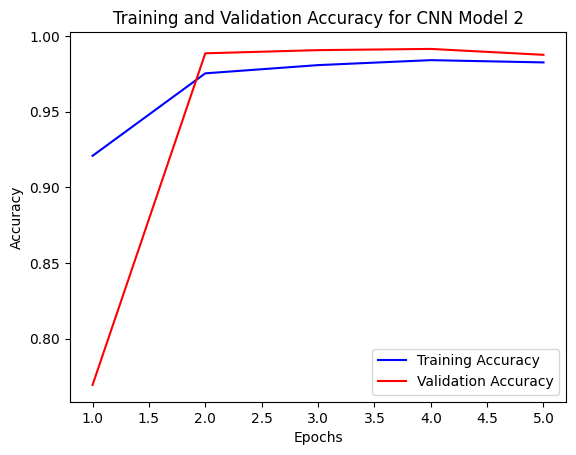

In [ ]:
# Retrieve the training and validation accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Get the number of epochs
epochs = range(1, len(train_accuracy) + 1)

# Plot the training and validation accuracy
plt.plot(epochs, train_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy for CNN Model 2')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()